In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('ggplot')

Траектория ушла в бесконечность на шаге 10 (для a=1.9516465)


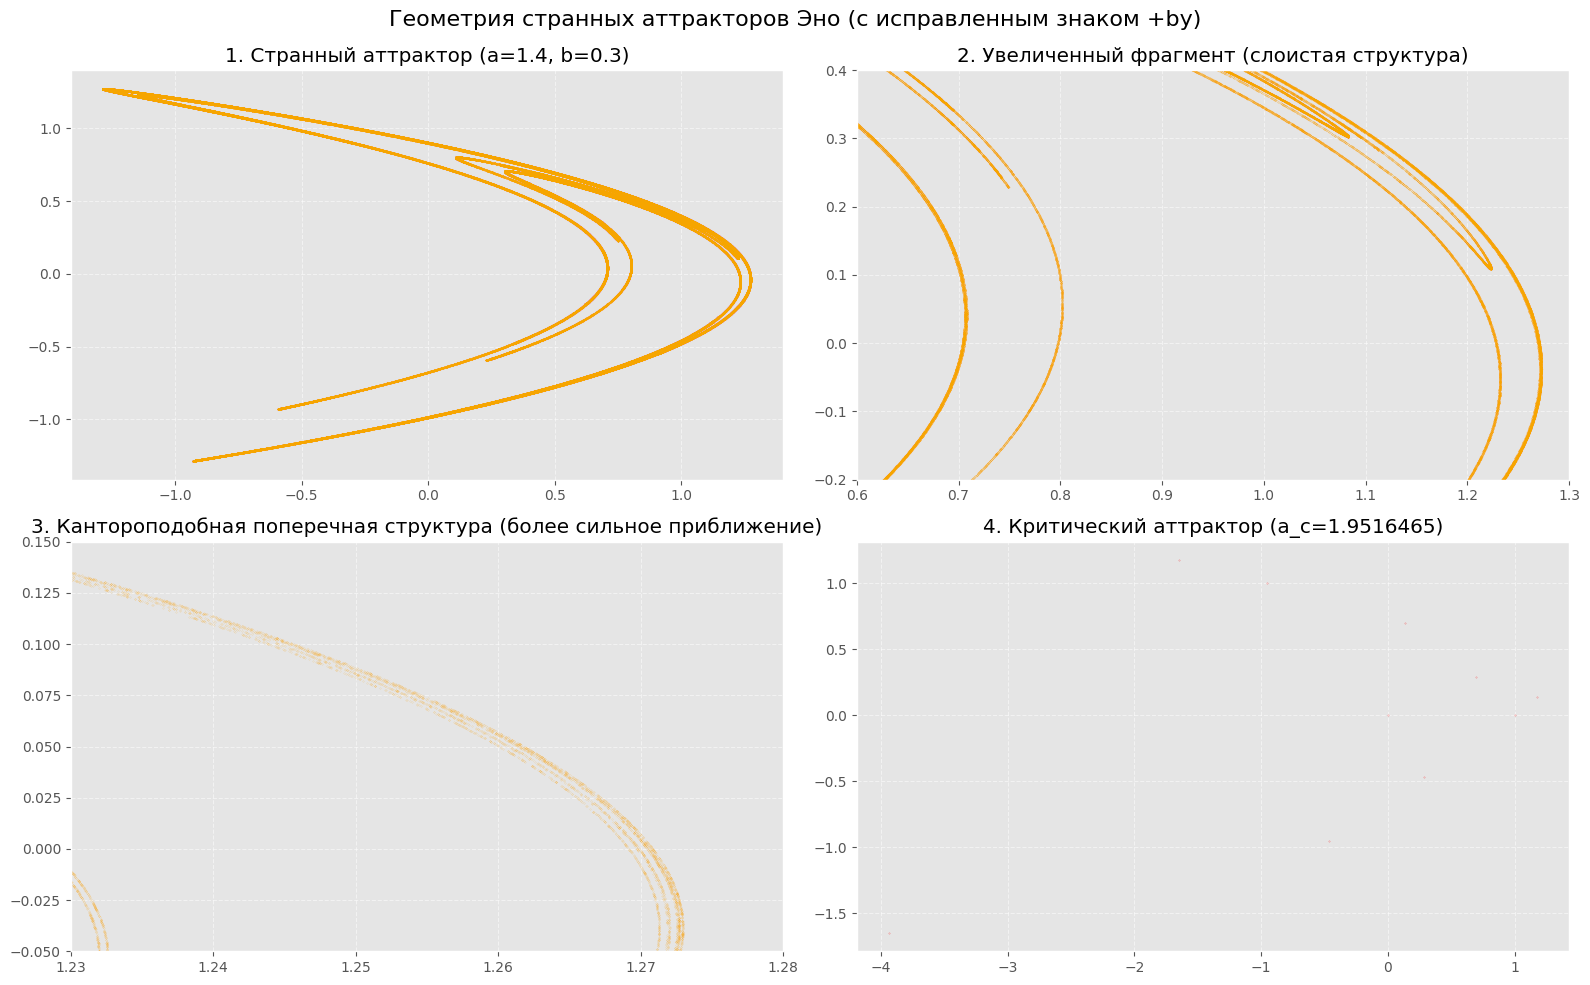

In [4]:
def henon_corrected(a, b, max_points=100000):
    x = np.zeros(max_points)
    y = np.zeros(max_points)
    x[0], y[0] = 0.0, 0.0
    for i in range(1, max_points):
        x[i] = 1 - a * x[i - 1] ** 2 + b * y[i - 1]
        y[i] = x[i - 1]
        if abs(x[i]) > 10:
            print(f"Траектория ушла в бесконечность на шаге {i} (для a={a})")
            return x[:i], y[:i]
    return x, y


b_val = 0.3
a_std = 1.4
a_crit = 1.9516465
x_std_full, y_std_full = henon_corrected(a_std, b_val, max_points=200000)
x_std = x_std_full[1000:]
y_std = y_std_full[1000:]
x_crit, y_crit = henon_corrected(a_crit, b_val, max_points=100000)
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Геометрия странных аттракторов Эно (с исправленным знаком +by)', fontsize=16)
marker_style = {'marker': '.', 'linestyle': 'None', 'markersize': 0.2, 'alpha': 0.7}

# 1. Полный стандартный аттрактор
ax1 = fig.add_subplot(2, 2, 1)
ax1.plot(x_std, y_std, color='orange', **marker_style)
ax1.set_title(f'1. Странный аттрактор (a={a_std}, b={b_val})')
ax1.grid(True, linestyle='--', alpha=0.5)
ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(x_std, y_std, color='orange', **marker_style)
ax2.set_xlim(0.6, 1.3)
ax2.set_ylim(-0.2, 0.4)
ax2.set_title('2. Увеличенный фрагмент (слоистая структура)')
ax2.grid(True, linestyle='--', alpha=0.5)

# 3. Увеличенный масштаб 2 (еще сильнее приближаем линии)
ax3 = fig.add_subplot(2, 2, 3)
ax3.plot(x_std, y_std, color='orange', **marker_style)
ax3.set_xlim(1.23, 1.28)
ax3.set_ylim(-0.05, 0.15)
ax3.set_title('3. Кантороподобная поперечная структура (более сильное приближение)')
ax3.grid(True, linestyle='--', alpha=0.5)

# 4. Критический аттрактор
ax4 = fig.add_subplot(2, 2, 4)
ax4.plot(x_crit, y_crit, color='red', marker='.', linestyle='None', markersize=0.5, alpha=0.5)
ax4.set_title(f'4. Критический аттрактор (a_c={a_crit})')
ax4.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()